# Try to run code with multiple images

In [1]:
from src.segmentation_pipeline import convex_segmentation, binary_fill_convex_segmentation
from src.model_run import start_prediction_machine, detectron2_instances
from src.classic_instances import instance_regions, make_instance_gif
from src.fusion import fusion_of_masks
from src.classifier import classify_instances, load_classifiers, Category_Classifier
from src.coco_json_functions import *
from src.model_run import CLASSES
from src.instance_based_evaluation import compare_coco
from tqdm import tqdm


from sklearn.base import TransformerMixin, BaseEstimator
class SelectColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, xs, ys, **params):
        return self
    def transform(self, xs):
        return xs[self.columns]
    
from pathlib import Path

In [2]:
# Image
# img_path = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/000018.tif"
img_paths = ["/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/000007.tif",
            "/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/000008.tif",
            "/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/000009.tif"]

img_annotations = ["/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000007.json",
                    "/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000008.json",
                    "/home/mellanie/Desktop/Annotated_dataset/20240925_N4_Plate1_DAG6_1000_L/labelme_annotations/000009.json"]

# Model to use
model_path = "/home/mellanie/Desktop/container/model/segmentation_models/instance_no_root.pth"

# Classifiers
bmp_cls = "/home/mellanie/Desktop/container/model/classifiers/bumps_embedded_classifier.pkl"
bg_cls = "/home/mellanie/Desktop/container/model/classifiers/bg_regular_classifier.pkl"

# Get the predictions into coco

In [3]:
# %%capture

# predictor is the segmentaion model as a variable
predictor = start_prediction_machine(path_to_model=model_path, instance_based=True)

# Make the classifier class
bmp_predictor, bg_predictor = load_classifiers(bmp_cls, bg_cls)
classifier = Category_Classifier(None, None, None, None, bmp_predictor, bg_predictor)


/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Tr

In [4]:

def instance_segmentation_pipeline(img_path):
    
    #1. Classic Segmentation
    #   function returns the mask for the root and the mask for the hairs as seperate variables
    root, hairs = binary_fill_convex_segmentation(img_path, save=False, verbose = False, show_overlay=True)

    #2. Separate Classic Segments by Instance
    #   get a list of each unique instance mask of root hairs
    classic_masks = instance_regions(hairs, root)
    
    #3. Get the Model outputs
    #   Instances is a list of all found instances in the image, including bounding box, mask, label, and label id
    model_instances = detectron2_instances(predictor, img_path, verbose=False)

    #4. Fuseion
    fused_instances = fusion_of_masks(classic_masks, model_instances)

    #5. Classify
    classified_instances = classify_instances(fused_instances, root, img_path, classifier)
    
    # # OPTIONAL: Destinguish between classic and model
    # classic_instances = [inst for inst in classified_instances if inst["case"] != "C"]
    # model_instances = [inst for inst in classified_instances if inst["case"] != "B"]

    # export_to_coco(classified_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/segmentation_outputs_coco.json")
    # export_to_coco(classic_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/classic_outputs_coco.json")
    # export_to_coco(model_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/model_outputs_coco.json")

    return classified_instances

Images:   0%|          | 0/3 [00:00<?, ?it/s]

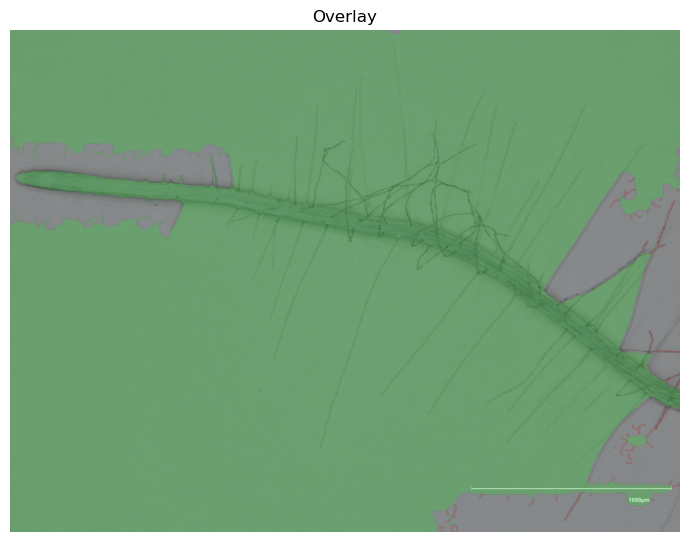

/home/mellanie/.local/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Pairing results:
  Case A (matched):  1
  Case B (classical only): 39
  Case C (DL only): 28


Images:  33%|███▎      | 1/3 [00:25<00:50, 25.37s/it]

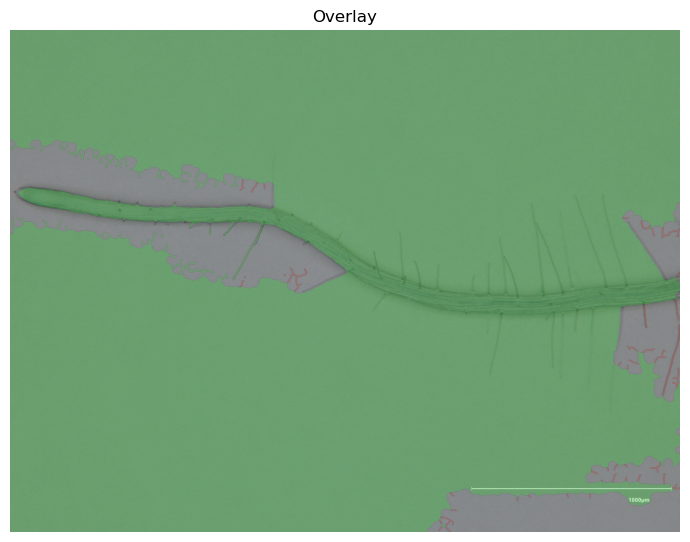

Pairing results:
  Case A (matched):  0
  Case B (classical only): 43
  Case C (DL only): 27


Images:  67%|██████▋   | 2/3 [00:46<00:22, 22.78s/it]

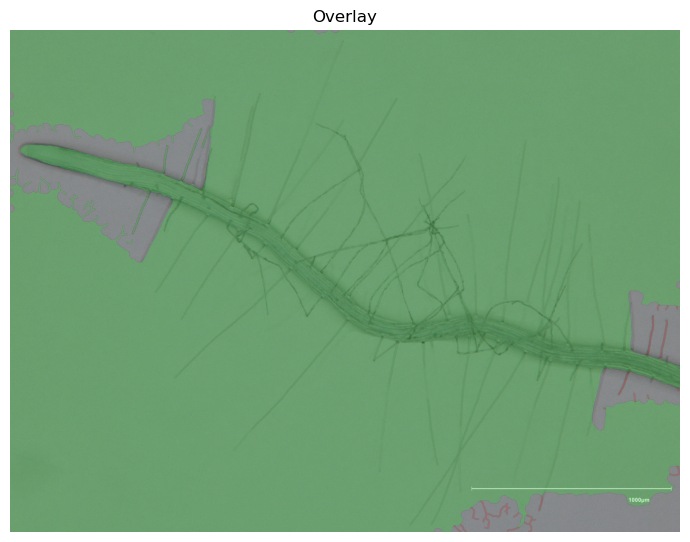

Pairing results:
  Case A (matched):  1
  Case B (classical only): 16
  Case C (DL only): 31


Images: 100%|██████████| 3/3 [01:09<00:00, 23.13s/it]


{'images': [{'id': 0,
   'file_name': '000007.tif',
   'width': 2048,
   'height': 1536},
  {'id': 1, 'file_name': '000008.tif', 'width': 2048, 'height': 1536},
  {'id': 2, 'file_name': '000009.tif', 'width': 2048, 'height': 1536}],
 'annotations': [{'id': 0,
   'image_id': 0,
   'category_id': 1,
   'segmentation': [[2019.0,
     1148.0,
     2004.0,
     1152.0,
     2002.0,
     1161.0,
     1971.0,
     1216.0,
     1960.0,
     1224.0,
     1943.0,
     1245.0,
     1957.0,
     1237.0,
     1964.0,
     1226.0,
     1977.0,
     1217.0,
     1995.0,
     1186.0,
     2018.0,
     1155.0]],
   'bbox': [1943.0, 1148.0, 77.0, 99.0],
   'area': 923.0,
   'iscrowd': 0},
  {'id': 1,
   'image_id': 0,
   'category_id': 6,
   'segmentation': [[614.0,
     381.0,
     614.0,
     401.0,
     628.0,
     484.0,
     632.0,
     485.0,
     632.0,
     460.0,
     623.0,
     423.0,
     618.0,
     381.0]],
   'bbox': [613.0, 381.0, 21.0, 105.0],
   'area': 759.0,
   'iscrowd': 0},
  {'id'

In [5]:

all_images = []
all_anns_full, all_anns_classic, all_anns_model = [], [], []

ann_id_full = ann_id_classic = ann_id_model = 0

image_id = 0
for img_path in tqdm(img_paths, desc="Images", colour="magenta"):
    classified_instances = instance_segmentation_pipeline(img_path)

    classic_instances = [inst for inst in classified_instances if inst["case"] != "C"]
    model_instances = [inst for inst in classified_instances if inst["case"] != "B"]

    # Tristan's Note:
    # we know this but perhaps change per image because user may have diff sies
    width, height = 2048, 1536 

    all_images.append({
        "id": image_id,
        "file_name": Path(img_path).name,
        "width": width,
        "height": height,
    })

    anns, ann_id_full = build_annotations_for_image(classified_instances, image_id, ann_id_full)
    all_anns_full.extend(anns)

    anns_c, ann_id_classic = build_annotations_for_image(classic_instances, image_id, ann_id_classic)
    all_anns_classic.extend(anns_c)

    anns_m, ann_id_model = build_annotations_for_image(model_instances, image_id, ann_id_model)
    all_anns_model.extend(anns_m)

    image_id += 1

write_coco_dataset(all_images, all_anns_full, CLASSES, "outputs/segmentation_outputs_coco.json")
write_coco_dataset(all_images, all_anns_classic, CLASSES, "outputs/classic_outputs_coco.json")
write_coco_dataset(all_images, all_anns_model, CLASSES, "outputs/model_outputs_coco.json")

# Get labelme annotations into coco

In [6]:
coco = labelme_files_to_coco(img_annotations, CLASSES, output_path="outputs/ground_truth_coco.json")

In [7]:
truth = "outputs/ground_truth_coco.json"
predicted = "outputs/model_outputs_coco.json"

compare_coco(truth, predicted)

Image ID: 0
TP=15  FP=12  FN=57
Precision=0.5556  Recall=0.2083  F1=0.3030

Image ID: 1
TP=24  FP=3  FN=34
Precision=0.8889  Recall=0.4138  F1=0.5647

Image ID: 2
TP=19  FP=12  FN=45
Precision=0.6129  Recall=0.2969  F1=0.4000

